Batch 0:
  Labels: [{'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'image_id': 'img_1125f4d1912c.jpg', 'letterbox_meta': {'scale': 0.64, 'pad_left': 0, 'pad_top': 40, 'orig_size': (500, 375)}}, {'boxes': tensor([[  0.0000, 206.4000, 136.9600, 279.3600],
        [216.3200,  61.7600, 290.5600, 201.2800],
        [ 36.4800,  90.5600,  96.0000, 194.2400],
        [ 16.6400, 125.1200, 172.1600, 280.0000]]), 'labels': tensor([4, 0, 0, 0]), 'image_id': 'img_6c1c22ebdc75.jpg', 'letterbox_meta': {'scale': 0.64, 'pad_left': 0, 'pad_top': 40, 'orig_size': (500, 375)}}, {'boxes': tensor([[ 72.9600,  46.4000, 320.0000, 194.8800]]), 'labels': tensor([0]), 'image_id': 'img_01ac0a0b4600.jpg', 'letterbox_meta': {'scale': 0.64, 'pad_left': 0, 'pad_top': 40, 'orig_size': (500, 375)}}, {'boxes': tensor([[ 56.9600, 132.8000, 249.6000, 279.3600]]), 'labels': tensor([0]), 'image_id': 'img_1496b2d1e8fa.jpg', 'letterbox_meta': {'scale': 0.64, 'pad_left': 0, 'pad_top': 40, 'orig_siz

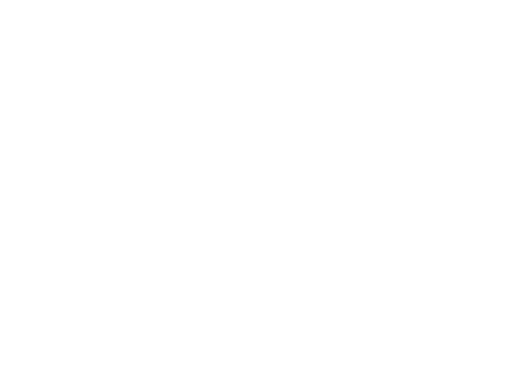

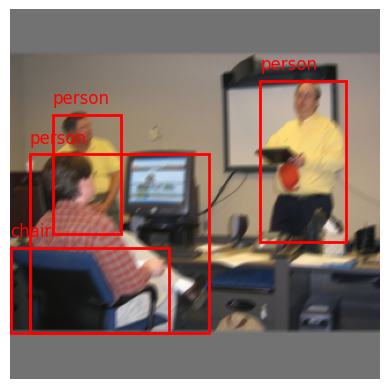

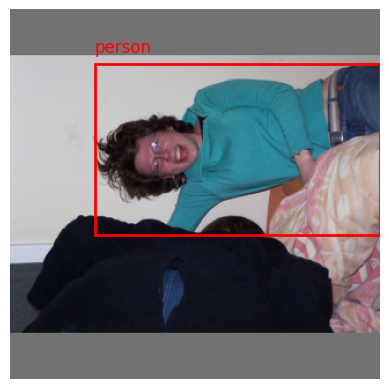

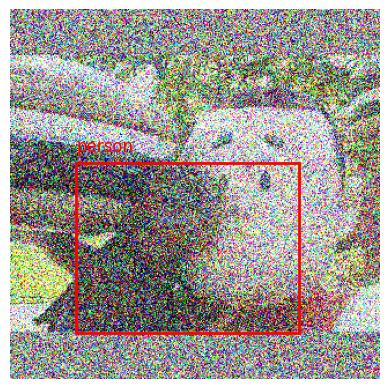

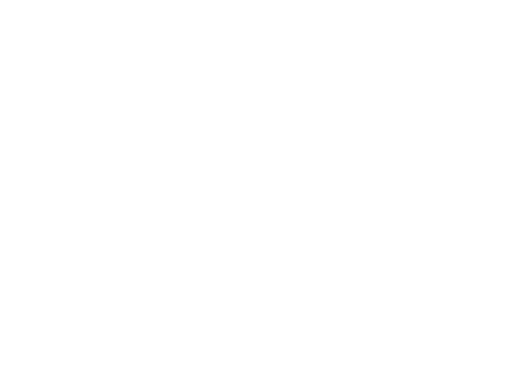

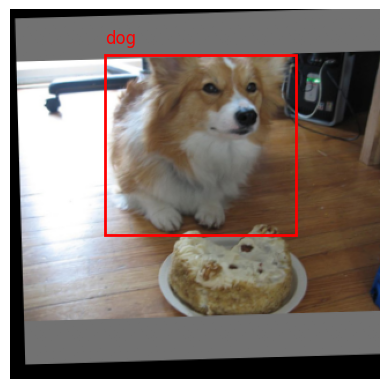

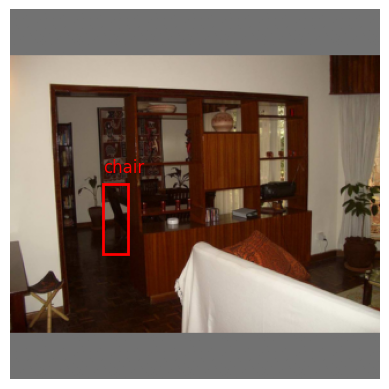

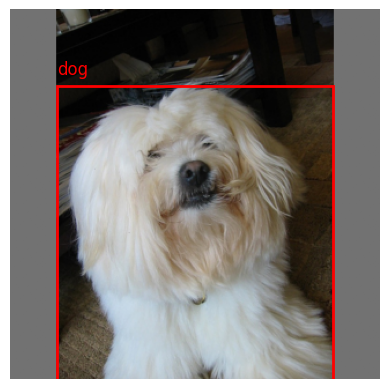

In [3]:
from dataloader import  build_visualized_loader,build_dataloader, albumentations_transform

train_loader = build_visualized_loader(
    data_root="final_public/public",
    split="train",
    transforms=albumentations_transform(),
)


def visualize_batch(images, labels):
    import matplotlib.pyplot as plt
    #images là 1 list
    # labels là list gồm các dict là {"boxes": boxes, "labels": labels, "image_id": img_id}
    #vẽ box lên ảnh
    labels_dict = {"person": 0, "car": 1, "dog": 2, "cat": 3, "chair": 4}
    batch_size = len(images)
    for i in range(batch_size):
        img = images[i].permute(1, 2, 0).numpy()  # Chuyển từ (C, H, W) sang (H, W, C)
        label = labels[i]
        boxes = label["boxes"]
        class_labels = label["labels"]
        for box, class_label in zip(boxes, class_labels):
            x_min, y_min, x_max, y_max = box
            class_name = list(labels_dict.keys())[list(labels_dict.values()).index(class_label)]
            # Vẽ bounding box
            plt.imshow(img)
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                              edgecolor='red', facecolor='none', linewidth=2))
            plt.text(x_min, y_min - 10, class_name, color='red', fontsize=12)
        plt.axis('off')
        plt.show()
for i, (images, labels) in enumerate(train_loader):
    print(f"Batch {i}:")
    #print(f"  Images: {images}")
    print(f"  Labels: {labels}")
    if i == 0:  # Just visualize the first batch
        visualize_batch(images, labels)

        break


In [1]:
import torch
from models.yolo import YOLOv8Scratch

model = YOLOv8Scratch(num_classes=3)

x = torch.randn(2, 3, 320, 320)

model.train()
out = model(x)

print(out["boxes_raw"].shape)
print(out["cls_logits"].shape)

torch.Size([2, 64, 2100])
torch.Size([2, 3, 2100])


In [2]:
model.eval()

with torch.no_grad():
    pred, raw = model(x)

print(pred.shape)

torch.Size([2, 7, 2100])
